<a href="https://colab.research.google.com/github/rrahulbharathwaj-r/Smart-Energy-Consumption-Predictor/blob/main/Day_3_equipment_failure_model_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Recreate data folder and model ---
os.makedirs('data', exist_ok=True)
np.random.seed(42)
n = 2000

temperature   = np.random.normal(70, 5, n)
pressure      = np.random.normal(2.5, 0.3, n)
ph            = np.random.normal(7.0, 0.4, n)
mixing_speed  = np.random.normal(200, 20, n)
humidity      = np.random.normal(45, 5, n)
reaction_time = np.random.normal(120, 10, n)

fail_prob = (
    (np.abs(temperature - 70) > 8).astype(int) * 0.5 +
    (np.abs(pressure - 2.5) > 0.5).astype(int) * 0.4 +
    (np.abs(ph - 7.0) > 0.6).astype(int) * 0.5 +
    (np.abs(mixing_speed - 200) > 35).astype(int) * 0.3 +
    (humidity > 55).astype(int) * 0.2
)
batch_quality = (fail_prob < np.random.uniform(0, 1, n)).astype(int)

df = pd.DataFrame({
    'temperature': temperature.round(2),
    'pressure': pressure.round(3),
    'ph': ph.round(3),
    'mixing_speed': mixing_speed.round(1),
    'humidity': humidity.round(2),
    'reaction_time': reaction_time.round(1),
    'batch_quality': batch_quality
})
df.to_csv('data/batch_quality_data.csv', index=False)

X = df.drop('batch_quality', axis=1)
y = df['batch_quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

with open('data/batch_quality_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# --- Generate equipment sensor data ---
n_machines = 5
timesteps = 200
records = []
for machine_id in range(n_machines):
    for t in range(timesteps):
        degradation = t / timesteps
        records.append({
            'machine_id': machine_id,
            'timestep': t,
            'vibration': np.random.normal(2.0 + degradation * 3, 0.3),
            'temperature': np.random.normal(60 + degradation * 20, 2),
            'pressure': np.random.normal(3.0 - degradation * 0.5, 0.2),
            'rpm': np.random.normal(1500 - degradation * 200, 50),
            'failure': 1 if t > 170 else 0
        })

equipment_df = pd.DataFrame(records)
equipment_df.to_csv('data/equipment_sensor_data.csv', index=False)
print("Batch quality model saved.")
print(f"Equipment data ready: {len(equipment_df)} records")
print(equipment_df.tail())

Batch quality model saved.
Equipment data ready: 1000 records
     machine_id  timestep  vibration  temperature  pressure          rpm  \
995           4       195   4.959508    81.517525  2.733135  1303.399060   
996           4       196   5.027200    80.257070  2.055572  1224.550520   
997           4       197   4.773481    78.576803  2.267644  1340.479129   
998           4       198   4.970636    79.370611  2.253769  1299.772757   
999           4       199   4.196995    79.574087  2.515137  1313.095749   

     failure  
995        1  
996        1  
997        1  
998        1  
999        1  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8580 - loss: 0.4550 - val_accuracy: 0.5972 - val_loss: 0.7919
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9074 - loss: 0.1990 - val_accuracy: 0.9028 - val_loss: 0.2487
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9136 - loss: 0.1587 - val_accuracy: 0.9722 - val_loss: 0.2108
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9614 - loss: 0.1146 - val_accuracy: 0.8889 - val_loss: 0.2939
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9691 - loss: 0.0836 - val_accuracy: 0.8889 - val_loss: 0.2433
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9707 - loss: 0.0756 - val_accuracy: 0.8889 - val_loss: 0.2213
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9784 - loss: 0.0634 - val_accuracy: 0.7917 - val_loss: 0.4232
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9614 - loss: 0.0948 - val_accuracy: 0.8472 - v

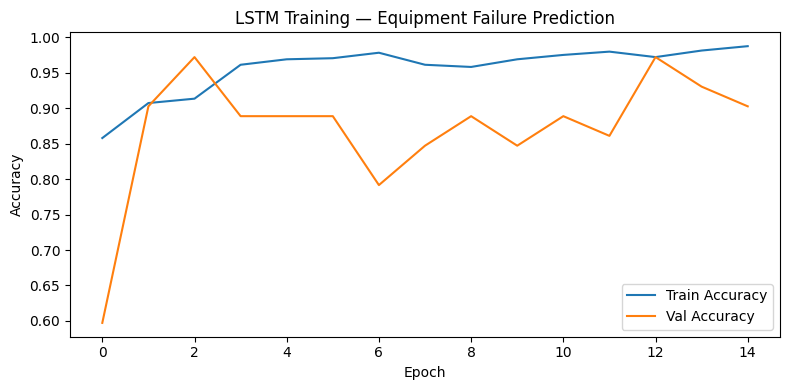

LSTM model done.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# --- Prepare sequences for LSTM ---
features = ['vibration', 'temperature', 'pressure', 'rpm']
sequence_length = 20

scaler = MinMaxScaler()
equipment_df[features] = scaler.fit_transform(equipment_df[features])

X_seq, y_seq = [], []
for machine_id in equipment_df['machine_id'].unique():
    machine_data = equipment_df[equipment_df['machine_id'] == machine_id]
    sensor_vals = machine_data[features].values
    labels = machine_data['failure'].values
    for i in range(len(sensor_vals) - sequence_length):
        X_seq.append(sensor_vals[i:i+sequence_length])
        y_seq.append(labels[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# --- Build LSTM ---
lstm_model = Sequential([
    LSTM(64, input_shape=(sequence_length, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history = lstm_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate ---
y_pred = (lstm_model.predict(X_test) > 0.5).astype(int)
print("\n=== EQUIPMENT FAILURE MODEL RESULTS ===")
print(classification_report(y_test, y_pred))

# --- Plot training ---
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Training — Equipment Failure Prediction')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
print("LSTM model done.")